# Linear Regression

Linear Regression is a type of supervised learning used to model the relationship between dependent and independent variable. Let $X$ be the space of all possible feature vectors, let $f: X \longrightarrow Y$
be the space of all possible corresponding labels for the feature vectors, and let  be the optimal target function assigning labels to feature vectors in $Y$ .

This notebook aims to predict individual medical costs billed by health insurance based on personal attributes such as age, BMI, and smoking status. Also will be using Scikit-Learn and a Single Neuron implementation.



### Data Preparation

Before training, I can convert categorical labels (like "smoker" or "region") into numerical values. Since gradient descent is sensitive to the scale of input data, can also apply Standard Scaling to ensure the model converges efficiently.


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset
df = pd.read_csv('insurance.csv')

# Encode categorical variables: 'sex', 'smoker', and 'region'
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

# Define features (X) and target (y)
X = df.drop('charges', axis=1).values
y = df['charges'].values

# Split and Scale the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()


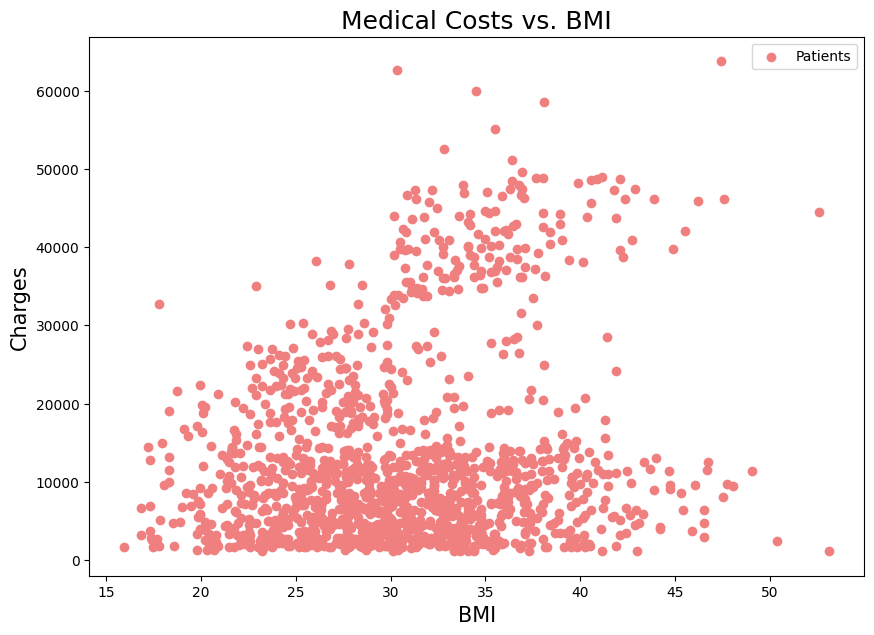

In [33]:
# Quick visualization of BMI vs Charges
plt.figure(figsize = (10, 7))
plt.scatter(df.bmi, df.charges, color = "lightcoral", label = "Patients")
plt.xlabel("BMI", fontsize = 15)
plt.ylabel("Charges", fontsize = 15)
plt.title("Medical Costs vs. BMI", fontsize = 18)
plt.legend()
plt.show()

### Linear Neuron Implemetantion

This class implements the basic unit of a neural network. It uses a Linear Activation Function and updates its weights (w) and bias (b) by calculating the gradient of the Mean Squared Error for every individual data point in the training set.

In [34]:
class LinearNeuron:
    def __init__(self, alpha=0.0001, epochs=100):
        self.alpha = alpha
        self.epochs = epochs

    def train(self, X, y):
        # Initialize weights randomly
        self.w_ = np.random.randn(X.shape[1])
        self.b_ = np.random.randn()
        self.loss_history = []

        for _ in range(self.epochs):
            epoch_loss = 0
            for xi, target in zip(X, y):
                # Prediction and Error calculation
                prediction = np.dot(xi, self.w_) + self.b_
                error = prediction - target

                # Gradient Descent update
                self.w_ -= self.alpha * error * xi
                self.b_ -= self.alpha * error

                epoch_loss += 0.5 * (error**2)
            self.loss_history.append(epoch_loss / len(X))
        return self

    def predict(self, X):
        return np.dot(X, self.w_) + self.b_

# Initialize and train
model = LinearNeuron(alpha=0.01, epochs=50)
model.train(X_train_scaled, y_train_scaled)

### Single Neuron class

Let's define the SingleNeuron class, which uses Stochastic Gradient Descent (SGD) to minimize the Mean Squared Error. This allows me to see the underlying math of a neural network.

In [35]:
class SingleNeuron(object):
    def __init__(self, activation_function):
        self.activation_function = activation_function

    def train(self, X, y, alpha = 0.005, epochs = 50):
        self.w_ = np.random.rand(1 + X.shape[1])
        self.errors_ = []
        N = X.shape[0]

        for _ in range(epochs):
            errors = 0
            for xi, target in zip(X, y):
                error = (self.predict(xi) - target)
                self.w_[:-1] -= alpha * error * xi
                self.w_[-1] -= alpha * error
                errors += .5 * (error**2)
            self.errors_.append(errors / N)
        return self

    def predict(self, X):
        preactivation = np.dot(X, self.w_[:-1]) + self.w_[-1]
        return self.activation_function(preactivation)

def linear_activation(z):
    return z

node = SingleNeuron(linear_activation)
node.train(X_train_scaled, y_train_scaled, alpha = 0.0001, epochs = 50)

### Model Visualisation
To evaluate performance, we plot the Actual vs. Predicted prices. If the model is accurate, the points should cluster tightly around the $y=x $ line.

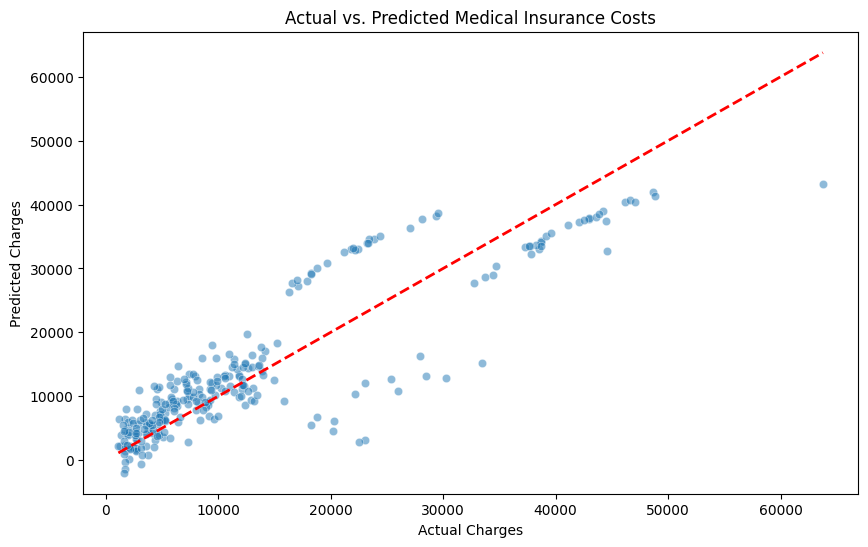

In [36]:
# Generate predictions on the test set
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# Plotting the results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs. Predicted Medical Insurance Costs")
plt.show()



Now, can also observe the decreasing trend of the MSE, which shows that our model is learning:

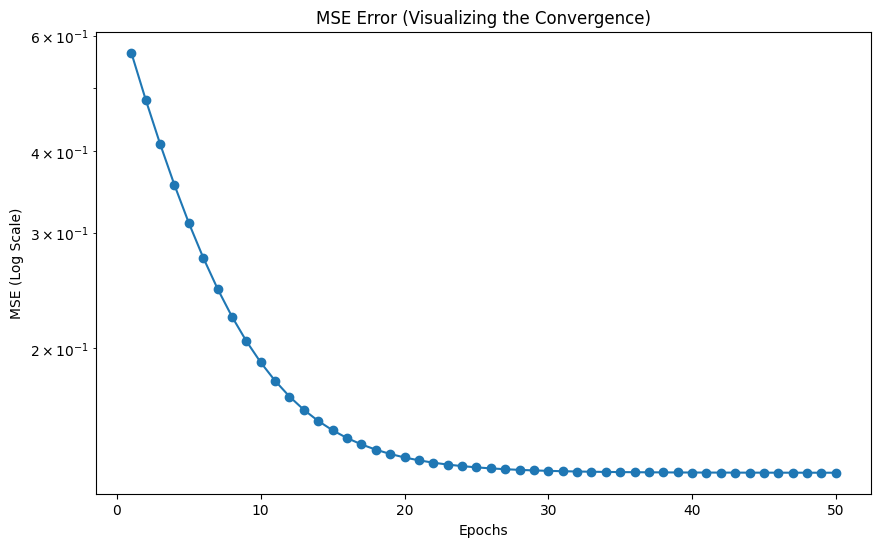

In [37]:
#MSE Loss Curve
plt.figure(figsize = (10, 6))
plt.plot(range(1, len(node.errors_) + 1), node.errors_, marker = "o")
plt.yscale('log') # This makes small changes visible
plt.xlabel("Epochs")
plt.ylabel("MSE (Log Scale)")
plt.title("MSE Error (Visualizing the Convergence)")
plt.show()

Finally, let's look at the learned weights to see which factors contribute most to medical costs. In this dataset, the smoker status typically has the highest coefficient, meaning it is the strongest predictor of high insurance charges.

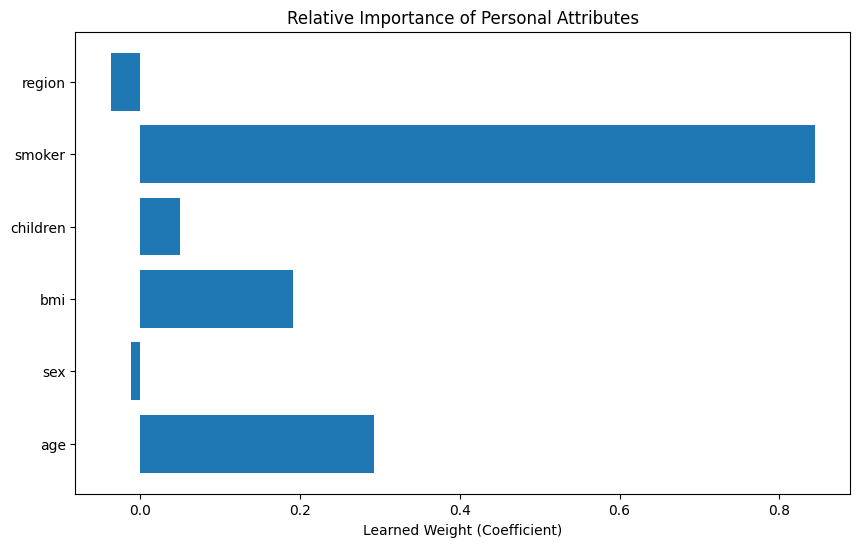

In [38]:
feature_names = df.drop('charges', axis=1).columns
plt.figure(figsize=(10, 6))
plt.barh(feature_names, model.w_)
plt.title("Relative Importance of Personal Attributes")
plt.xlabel("Learned Weight (Coefficient)")
plt.show()

Conclusion:
The model successfully identifies key trends in healthcare costs. By implementing this as a custom neuron rather than using a standard library, I was able to observe how the Loss Curve stabilized over time and how different learning rates influenced the final accuracy of the predictions.